# Test MODFLOW New Style

## Packages

In [ ]:
from pathlib import Path

import flopy
import pandas as pd
import pastas as ps
from pastas.timer import SolveTimer

from pastas_plugins import modflow as ppmf

ps.show_versions()

In [ ]:
bindir = Path("bin")
if not (bindir / "mf6").exists():
    bindir.mkdir(parents=True, exist_ok=True)
    flopy.utils.get_modflow(bindir, repo="modflow6")

ps.set_use_cache(True)

ppmf.set_log_level("ERROR")

Pastas     : 2.0.0
Python     : 3.13.11
Numpy      : 2.4.4
Pandas     : 2.3.3
Scipy      : 1.17.1
Matplotlib : 3.10.9
Numba      : 0.65.1



## Load Data

In [3]:
ds = {
    "rain": pd.read_csv("rain.csv", index_col=0, parse_dates=True),
    "head": pd.read_csv("head.csv", index_col=0, parse_dates=True),
    "evap": pd.read_csv("evap.csv", index_col=0, parse_dates=True),
}
head = ds["head"].squeeze().dropna()
prec = ds["rain"].squeeze().dropna().resample("D").asfreq().fillna(0.0)
evap = ds["evap"].squeeze().dropna()

## Test

### Pastas Model

In [4]:
ml = ps.Model(head, name="pastas")
rm = ps.RechargeModel(prec, evap, rfunc=ps.Exponential(), name="rch")
ml.add_stressmodel(rm)
ml.solve()

Fit report pastas                   Fit Statistics
nfev     11                     EVP          87.10
nobs     5737                   R2            0.87
noise    False                  RMSE          0.42
tmin     2003-01-01 00:00:00    AICc      -9870.13
tmax     2018-12-25 00:00:00    BIC       -9843.52
freq     D                      Obj         512.71
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
               optimal    initial  vary
rch_A       331.307215  29.925748  True
rch_a        98.429448  10.000000  True
rch_f        -0.854497  -1.000000  True
constant_d  -14.150450 -11.740288  True


<Axes: xlabel='Date', ylabel='Head'>

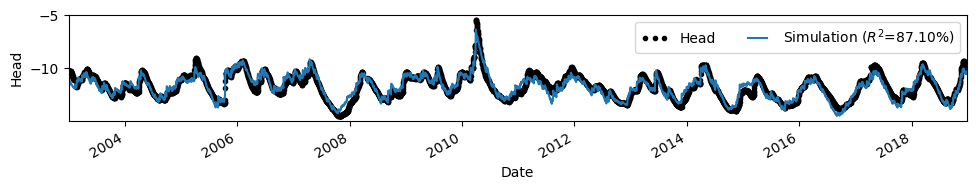

In [ ]:
ml.plot(figsize=(10, 3));

### Pastas Model with MODFLOW plugin

In [6]:
ml1 = ps.Model(head, name="mftest")
mfml = ppmf.ModflowModel(
    model=ml1,
    exe_name=bindir / "mf6",
    sim_ws=Path("mftest"),
    silent=True,
)
ghb = ppmf.ModflowGhb()
rch = ppmf.ModflowRch(prec, evap)
mfml.add_modflow_package([ghb, rch])
ml1.add_stressmodel(mfml)
with SolveTimer() as t:
    ml1.solve(diff_step=1e-4, callback=t.timer)

Optimization progress: 0it [00:00, ?it/s]

Fit report mftest                   Fit Statistics
nfev     25                     EVP          87.09
nobs     5737                   R2            0.87
noise    False                  RMSE          0.42
tmin     2003-01-01 00:00:00    AICc      -9866.39
tmax     2018-12-25 00:00:00    BIC       -9839.78
freq     D                      Obj         513.05
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
              optimal    initial   vary
DIS_H        0.000000   0.000000  False
STO_S        0.295420   0.100000   True
constant_d -14.154944 -11.740288   True
GHB_C        0.003018   0.001000   True
RCH_f       -0.853401  -1.000000   True

Warnings! (1)
Parameter 'DIS_H' on lower bound: 0.00e+00


<Axes: xlabel='Date', ylabel='Head'>

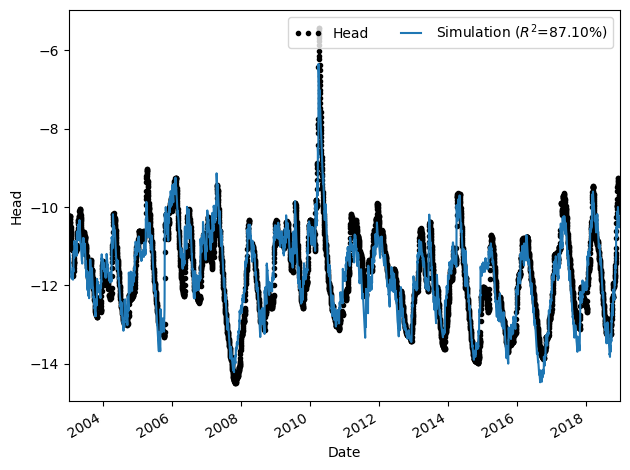

In [ ]:
ml.plot(figsize=(10, 3));

In [8]:
ml2 = ps.Model(head, name="mftest")
mfml2 = ppmf.ModflowModelApi(
    model=ml2,
    dll=bindir / "libmf6.so",
    sim_ws=Path("/dev/shm/mftest2"),
    silent=True,
)
ghb = ppmf.ModflowGhb()
rch = ppmf.ModflowRch(prec, evap)
mfml2.add_modflow_package([ghb, rch])
ml2.add_stressmodel(mfml2)
with SolveTimer() as t:
    ml2.solve(diff_step=1e-4, callback=t.timer)

Optimization progress: 0it [00:00, ?it/s]

Fit report mftest                   Fit Statistics
nfev     28                     EVP          87.09
nobs     5737                   R2            0.87
noise    False                  RMSE          0.42
tmin     2003-01-01 00:00:00    AICc      -9866.39
tmax     2018-12-25 00:00:00    BIC       -9839.78
freq     D                      Obj         513.05
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
              optimal    initial   vary
DIS_H        0.000000   0.000000  False
STO_S        0.295384   0.100000   True
constant_d -14.155587 -11.740288   True
GHB_C        0.003018   0.001000   True
RCH_f       -0.853073  -1.000000   True

Warnings! (1)
Parameter 'DIS_H' on lower bound: 0.00e+00


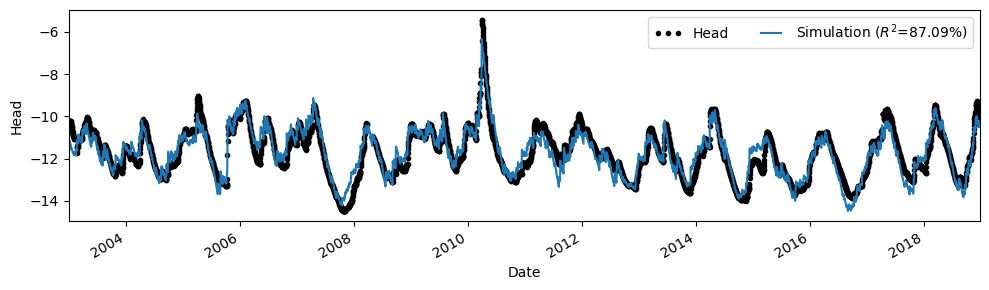

In [9]:
ml2.plot(figsize=(10, 3));

Compare simulate speed.

In [14]:
p = ml1.parameters.optimal.add(1e-6).tolist() # nudge parameters to avoid cache hit

In [15]:
%%timeit
ml1.simulate(p)

331 μs ± 121 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%%timeit
ml2.simulate(p)

354 μs ± 121 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
